# Day 2: Clustering with K-Means - Solutions

**⚠️ Important:** Try to solve the exercises yourself before looking at these solutions! The learning happens when you struggle with the problems.

---

## Setup

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin

sns.set_style('whitegrid')
%matplotlib inline

# Generate the same dataset
features, true_labels = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

---

## Task 1: Initialize Cluster Centers

### Solution:

In [2]:
def initialize_centers(data, k):
    """
    Initialize K cluster centers by randomly selecting K data points.
    """
    n_samples = data.shape[0]
    # Randomly select k indices without replacement
    indices = np.random.choice(n_samples, k, replace=False)
    # Get the corresponding data points
    centers = data[indices]
    
    return centers

# Test the function
np.random.seed(42)  # For reproducibility
initial_centers = initialize_centers(features, k=4)
print("Initial cluster centers shape:", initial_centers.shape)
print("Initial centers:")
print(initial_centers)

Initial cluster centers shape: (4, 2)
Initial centers:
[[-3.05358035  9.12520872]
 [-8.71022334  6.64247126]
 [-9.41396558  7.44553273]
 [-9.05929193  7.35040875]]


### Explanation:

- **`np.random.choice(n_samples, k, replace=False)`** randomly selects k unique indices from 0 to n_samples-1
- **`replace=False`** ensures we don't select the same point twice
- **`data[indices]`** uses NumPy's fancy indexing to get the k data points at those indices
- The result is a (k, n_features) array containing k initial cluster centers
- This is called the **Forgy initialization method** - simple but effective

**Alternative approach:** You could also use `data[np.random.permutation(n_samples)[:k]]` which shuffles all indices and takes the first k.

---

## Task 2: Assign Points to Nearest Cluster

### Solution:

In [3]:
def assign_clusters(data, centers):
    """
    Assign each data point to the nearest cluster center.
    """
    # Option 1: Use sklearn's efficient implementation
    labels = pairwise_distances_argmin(data, centers)
    
    return labels

# Test the function
cluster_assignments = assign_clusters(features, initial_centers)
print("Cluster assignments shape:", cluster_assignments.shape)
print("First 10 assignments:", cluster_assignments[:10])
print("Unique clusters:", np.unique(cluster_assignments))

Cluster assignments shape: (500,)
First 10 assignments: [1 1 0 0 1 1 1 1 0 1]
Unique clusters: [0 1 2 3]


### Explanation:

- **`pairwise_distances_argmin(data, centers)`** calculates the distance from each data point to each center and returns the index of the closest center
- This is efficient and handles the entire dataset at once using vectorized operations
- The result is an array of length n_samples where each value is between 0 and k-1

**Alternative implementation (manual):**

```python
def assign_clusters_manual(data, centers):
    labels = np.zeros(len(data), dtype=int)
    for i, point in enumerate(data):
        # Calculate distance to each center
        distances = np.linalg.norm(centers - point, axis=1)
        # Assign to closest center
        labels[i] = np.argmin(distances)
    return labels
```

This manual version is slower but more intuitive - it loops through each point and calculates Euclidean distance to all centers.

---

## Task 3: Update Cluster Centers

### Solution:

In [4]:
def update_centers(data, labels, k):
    """
    Update cluster centers to the mean of assigned points.
    """
    n_features = data.shape[1]
    new_centers = np.zeros((k, n_features))
    
    for j in range(k):
        # Get all points assigned to cluster j using boolean indexing
        cluster_points = data[labels == j]
        
        # Calculate mean along axis 0 (average each feature separately)
        if len(cluster_points) > 0:  # Handle empty clusters
            new_centers[j] = np.mean(cluster_points, axis=0)
        else:
            # If cluster is empty, keep the old center (or reinitialize)
            new_centers[j] = new_centers[j]  # This maintains zeros
    
    return new_centers

# Test the function
updated_centers = update_centers(features, cluster_assignments, k=4)
print("Updated cluster centers:")
print(updated_centers)
print("\nCenter movement (distance from initial):")
for i in range(4):
    distance = np.linalg.norm(updated_centers[i] - initial_centers[i])
    print(f"  Cluster {i}: moved {distance:.2f} units")

Updated cluster centers:
[[ 1.05980458  5.50814533]
 [-7.30150873 -3.48732756]
 [-9.62524775  7.88630253]
 [-8.44203539  8.05797364]]

Center movement (distance from initial):
  Cluster 0: moved 5.48 units
  Cluster 1: moved 10.23 units
  Cluster 2: moved 0.49 units
  Cluster 3: moved 0.94 units


### Explanation:

- **`data[labels == j]`** uses boolean indexing to select only the points assigned to cluster j
- **`np.mean(cluster_points, axis=0)`** calculates the mean along axis 0, which averages each column (feature) separately
  - axis=0 means "collapse the rows" → result is one row (the mean)
  - For example, if cluster_points is [[1, 2], [3, 4]], mean is [2, 3]
- **Empty cluster handling:** In rare cases, a cluster might have no assigned points. We check `len(cluster_points) > 0` to avoid warnings
- The centers "move" toward the average position of their assigned points - this is the key to K-Means convergence!

**Mathematical intuition:** Each iteration, the centers move to the "center of mass" of their cluster. Eventually, they stabilize when moving them further wouldn't change assignments.

---

## Task 4: Complete K-Means Algorithm

### Solution:

In [5]:
def k_means(data, k, max_iter=100, tolerance=1e-4):
    """
    Complete K-Means clustering algorithm.
    """
    # Initialize centers using our function
    centers = initialize_centers(data, k)
    
    for iteration in range(max_iter):
        # Step 1: Assign points to clusters
        labels = assign_clusters(data, centers)
        
        # Step 2: Update centers
        new_centers = update_centers(data, labels, k)
        
        # Check for convergence: have centers stopped moving?
        center_shift = np.linalg.norm(new_centers - centers)
        
        if center_shift < tolerance:
            print(f"Converged after {iteration + 1} iterations")
            centers = new_centers
            break
        
        # Update for next iteration
        centers = new_centers
    else:
        # This runs if we didn't break (i.e., reached max_iter)
        print(f"Reached max iterations ({max_iter})")
    
    # Final assignment with converged centers
    labels = assign_clusters(data, centers)
    
    return labels, centers, iteration + 1

# Run K-Means
np.random.seed(42)
my_labels, my_centers, n_iterations = k_means(features, k=4)

print(f"\nClustering completed in {n_iterations} iterations")
print(f"\nFinal cluster centers:")
print(my_centers)
print(f"\nCluster sizes:")
unique, counts = np.unique(my_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} points")

Converged after 5 iterations

Clustering completed in 5 iterations

Final cluster centers:
[[ 4.72182456  1.9238556 ]
 [-7.0009649  -6.90445754]
 [-8.68153751  7.4554521 ]
 [-2.60221541  9.09243505]]

Cluster sizes:
  Cluster 0: 125 points
  Cluster 1: 125 points
  Cluster 2: 125 points
  Cluster 3: 125 points


### Explanation:

- **Initialization:** Start with random centers
- **Main loop:** Alternate between assigning points and updating centers
- **Convergence check:** Calculate how much centers moved using `np.linalg.norm()` (Euclidean distance)
  - If movement < tolerance, the algorithm has converged
  - This is more efficient than running all max_iter iterations
- **for-else construct:** The `else` clause after a for loop runs only if the loop completed without breaking
  - If we converge early, we `break` and the else doesn't run
  - If we reach max_iter, the else runs and prints a message

**Why K-Means converges:**
- Each iteration either improves the clustering or leaves it unchanged
- There are a finite number of possible assignments
- Therefore, it must eventually stabilize

**Typical behavior:**
- Converges in 10-20 iterations for simple data
- May take longer for complex or high-dimensional data
- Different initializations may converge to different solutions

---

## Visualize Results

Let's create a comprehensive visualization comparing our implementation with the true labels:

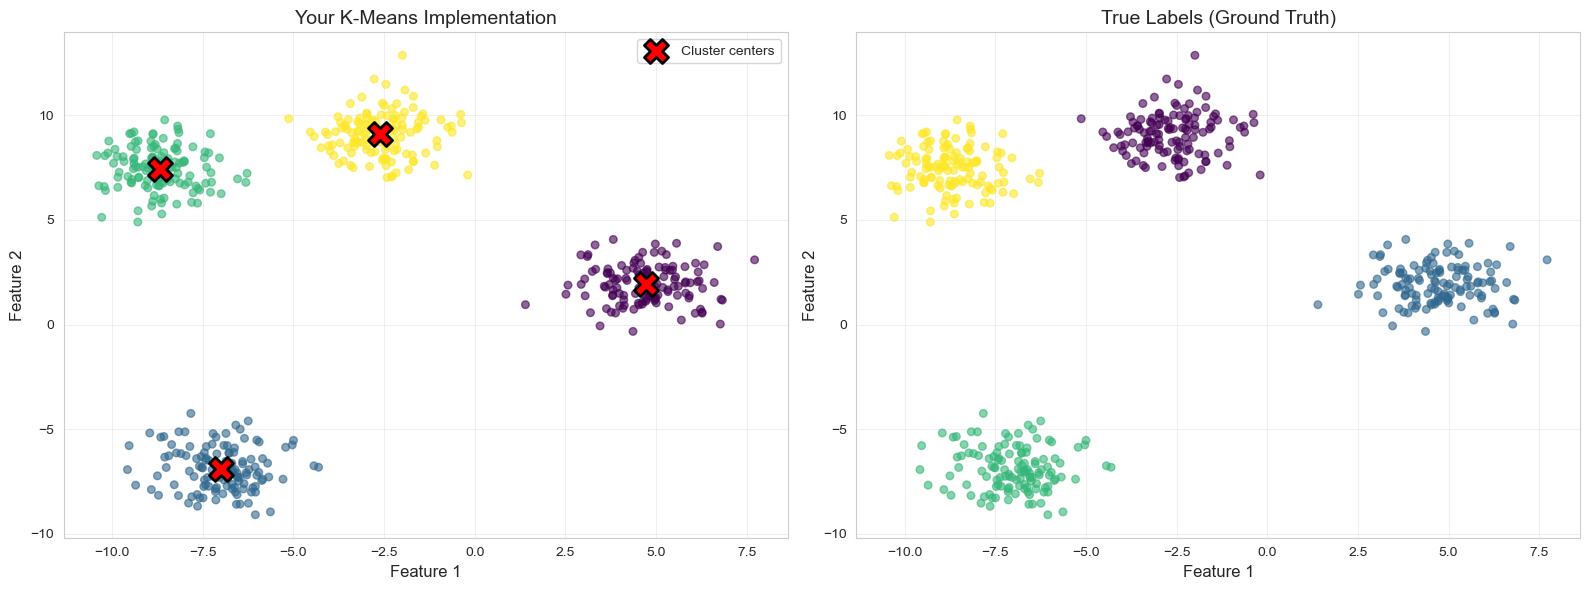


Note: Cluster colors may differ between plots because cluster IDs are arbitrary.
What matters is that similar points are grouped together!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Our K-Means results
axes[0].scatter(features[:, 0], features[:, 1], s=30, alpha=0.6, 
                c=my_labels, cmap='viridis')
axes[0].scatter(my_centers[:, 0], my_centers[:, 1], 
                s=300, c='red', marker='X', edgecolors='black', linewidths=2,
                label='Cluster centers')
axes[0].set_xlabel('Feature 1', fontsize=12)
axes[0].set_ylabel('Feature 2', fontsize=12)
axes[0].set_title('Your K-Means Implementation', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# True labels
axes[1].scatter(features[:, 0], features[:, 1], s=30, alpha=0.6, 
                c=true_labels, cmap='viridis')
axes[1].set_xlabel('Feature 1', fontsize=12)
axes[1].set_ylabel('Feature 2', fontsize=12)
axes[1].set_title('True Labels (Ground Truth)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNote: Cluster colors may differ between plots because cluster IDs are arbitrary.")
print("What matters is that similar points are grouped together!")

---

## Using Scikit-learn's KMeans

Now let's compare with sklearn's optimized implementation:

In [7]:
# Sklearn implementation
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
sklearn_labels = kmeans.fit_predict(features)
sklearn_centers = kmeans.cluster_centers_

print("Sklearn KMeans results:")
print(f"Number of iterations: {kmeans.n_iter_}")
print(f"Inertia: {kmeans.inertia_:.2f}")

# Calculate inertia for our implementation
my_inertia = 0
for i in range(len(features)):
    center = my_centers[my_labels[i]]
    my_inertia += np.sum((features[i] - center) ** 2)

print(f"\nYour implementation inertia: {my_inertia:.2f}")
print("\n(Lower inertia = better clustering. Small differences are due to initialization)")

Sklearn KMeans results:
Number of iterations: 2
Inertia: 948.89

Your implementation inertia: 948.89

(Lower inertia = better clustering. Small differences are due to initialization)


C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


---

## Exercise 1: Elbow Method

### Solution:

C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\minic

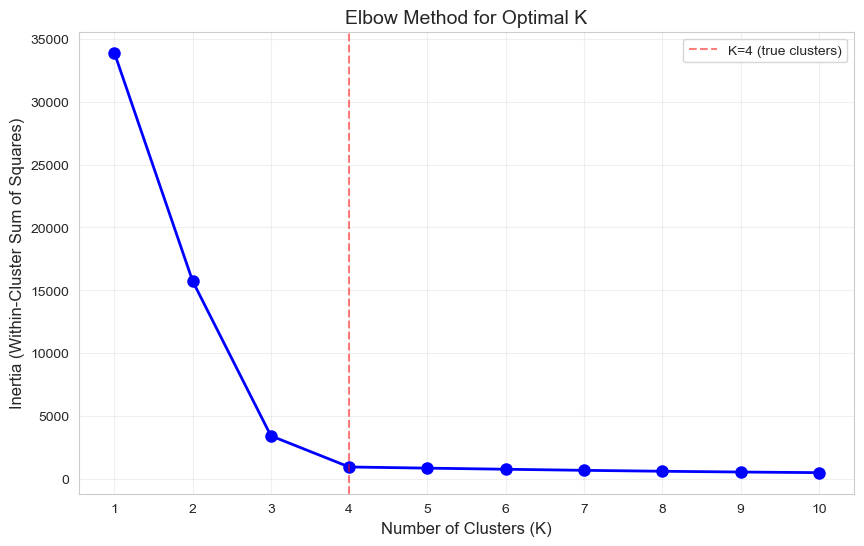

Inertia values:
  K=1: 33903.90
  K=2: 15737.08
  K=3: 3426.26
  K=4: 948.89
  K=5: 856.47
  K=6: 768.04
  K=7: 681.35
  K=8: 608.54
  K=9: 546.79
  K=10: 497.99


In [8]:
# Implement the Elbow Method
k_values = range(1, 11)
inertias = []

for k in k_values:
    # Fit KMeans with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    # Append inertia to list
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Highlight K=4 (the true number)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='K=4 (true clusters)')
plt.legend()
plt.show()

print("Inertia values:")
for k, inertia in zip(k_values, inertias):
    print(f"  K={k}: {inertia:.2f}")

### Explanation:

- **Inertia** is the sum of squared distances from each point to its cluster center
  - Lower inertia means points are closer to their centers
  - Inertia always decreases as K increases
- **The elbow** is where the curve starts to flatten
  - Before the elbow: large decreases in inertia (adding clusters helps a lot)
  - After the elbow: small decreases (diminishing returns)
- **For our data:** You should see an elbow around K=4, matching the true number of clusters
- **`n_init=10`** means sklearn runs K-Means 10 times with different initializations and picks the best result

**Important note:** The elbow method is subjective! Different people might identify different elbows. Always combine with:
- Domain knowledge
- Silhouette scores
- Visual inspection of clusters

---

## Exercise 2: Customer Segmentation

### Solution:

C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\minic

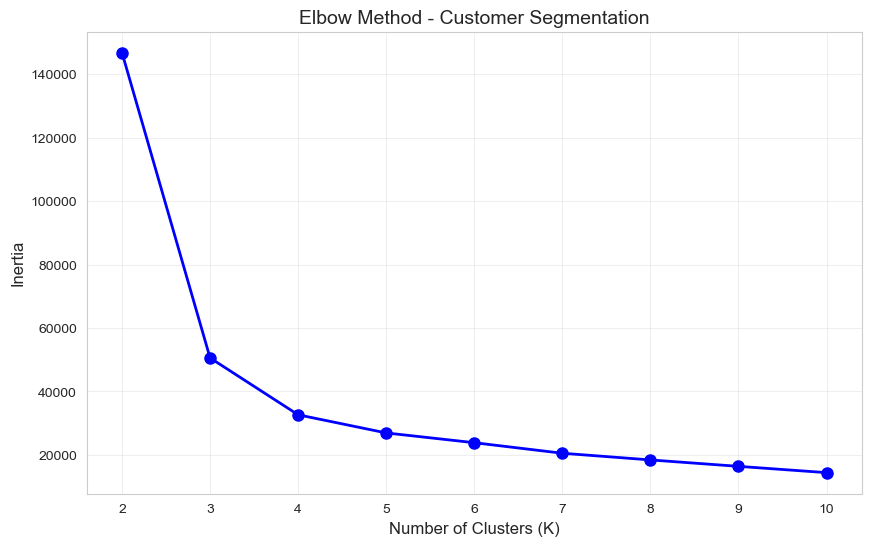


Based on the elbow plot, K=5 appears optimal (where the curve flattens).


In [9]:
# Generate customer data
np.random.seed(42)
customer_data, _ = make_blobs(
    n_samples=300,
    centers=5,
    cluster_std=8,
    center_box=(20, 100),
    random_state=42
)

customer_data[:, 0] = np.clip(customer_data[:, 0], 20, 100)  # Income
customer_data[:, 1] = np.clip(customer_data[:, 1], 1, 100)   # Spending

# Apply Elbow Method
k_values = range(2, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(customer_data)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method - Customer Segmentation', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

print("\nBased on the elbow plot, K=5 appears optimal (where the curve flattens).")

In [10]:
# Apply K-Means with optimal K
optimal_k = 5  # Based on elbow plot

kmeans_customer = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_labels = kmeans_customer.fit_predict(customer_data)
customer_centers = kmeans_customer.cluster_centers_

# Visualize customer segments
plt.figure(figsize=(12, 8))
scatter = plt.scatter(customer_data[:, 0], customer_data[:, 1], 
                     s=50, alpha=0.6, c=customer_labels, cmap='viridis')
plt.scatter(customer_centers[:, 0], customer_centers[:, 1], 
           s=400, c='red', marker='X', edgecolors='black', linewidths=3,
           label='Segment Centers')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'Customer Segmentation (K={optimal_k} segments)', fontsize=14)
plt.colorbar(scatter, label='Segment ID')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Print segment statistics
print("\nSegment Statistics:")
print("=" * 60)
for i in range(optimal_k):
    segment_data = customer_data[customer_labels == i]
    avg_income = segment_data[:, 0].mean()
    avg_spending = segment_data[:, 1].mean()
    size = len(segment_data)
    
    print(f"\nSegment {i}:")
    print(f"  Size: {size} customers")
    print(f"  Avg Income: ${avg_income:.1f}k")
    print(f"  Avg Spending Score: {avg_spending:.1f}")
    
    # Classify segment
    if avg_income > 65 and avg_spending > 60:
        segment_type = "Premium Customers (High value)"]
    elif avg_income < 45 and avg_spending < 40:
        segment_type = "Budget-Conscious (Price sensitive)"
    elif avg_spending > 60:
        segment_type = "High Spenders (Marketing opportunity)"
    elif avg_income > 65:
        segment_type = "High Income, Low Engagement (Untapped potential)"
    else:
        segment_type = "Average Customers (Standard offers)"
    
    print(f"  Classification: {segment_type}")

SyntaxError: unmatched ']' (2332896624.py, line 40)

### Explanation:

- **Elbow at K=5:** The plot shows that 5 clusters provide a good balance between detail and simplicity
- **Segment interpretation:** By analyzing average income and spending, we can characterize each segment:
  - **Premium Customers:** High income, high spending → target with premium products
  - **Budget-Conscious:** Low income, low spending → target with discounts and value deals
  - **High Spenders:** Medium income but high spending → loyal customers, upsell opportunities
  - **Untapped Potential:** High income but low spending → need engagement campaigns
  - **Average:** Middle ground → standard marketing approach

**Business implications:**
1. **Personalized marketing:** Different campaigns for each segment
2. **Resource allocation:** Focus on high-value segments
3. **Product development:** Design products for specific segments
4. **Customer retention:** Identify at-risk segments (e.g., decreasing spending)

**Important considerations:**
- Real customer data would have more features (age, location, purchase history, etc.)
- Always validate segments with business stakeholders
- Segments should be actionable - can you target them differently?
- Re-run clustering periodically as customer behavior changes

---

## Bonus: Comparing Initialization Methods

C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


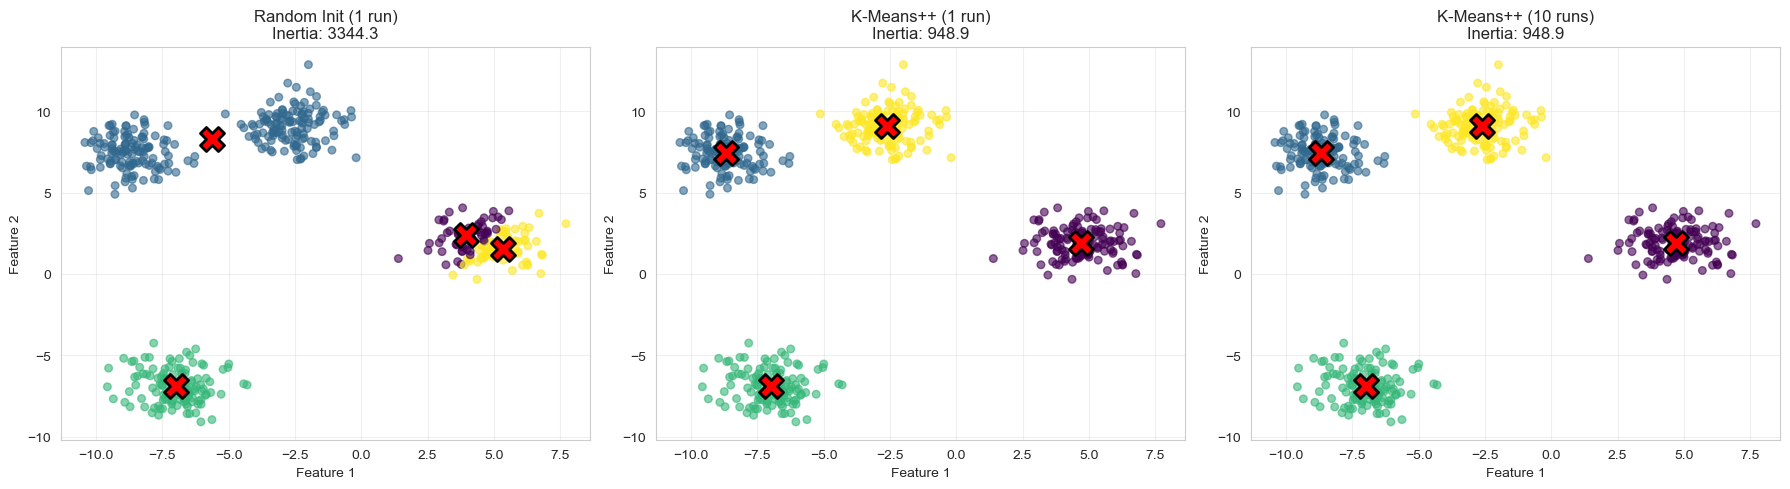


Key insights:
- Random initialization can lead to suboptimal results
- K-Means++ initialization (sklearn default) spreads centers better
- Multiple runs (n_init=10) help find the global optimum
- Lower inertia = better clustering


In [13]:
# Compare different initialization methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
init_methods = ['random', 'k-means++', 'k-means++']
n_inits = [1, 1, 10]
titles = ['Random Init (1 run)', 'K-Means++ (1 run)', 'K-Means++ (10 runs)']

for ax, init, n_init, title in zip(axes, init_methods, n_inits, titles):
    kmeans = KMeans(n_clusters=4, init=init, n_init=n_init, random_state=42)
    labels = kmeans.fit_predict(features)
    
    ax.scatter(features[:, 0], features[:, 1], s=30, alpha=0.6, 
              c=labels, cmap='viridis')
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
              s=300, c='red', marker='X', edgecolors='black', linewidths=2)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'{title}\nInertia: {kmeans.inertia_:.1f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey insights:")
print("- Random initialization can lead to suboptimal results")
print("- K-Means++ initialization (sklearn default) spreads centers better")
print("- Multiple runs (n_init=10) help find the global optimum")
print("- Lower inertia = better clustering")

---

## Summary

You've successfully:

✓ Implemented K-Means from scratch and understood each step  
✓ Used sklearn's optimized KMeans implementation  
✓ Applied the Elbow Method to find optimal K  
✓ Solved a real-world customer segmentation problem  
✓ Learned about K-Means limitations and best practices  

### Key Takeaways:

1. **K-Means is iterative:** Alternate between assignment and update steps
2. **Convergence is guaranteed:** But may find local optima (use multiple initializations)
3. **Choosing K is crucial:** Use Elbow Method, Silhouette Score, or domain knowledge
4. **Preprocessing matters:** Scale features and handle outliers before clustering
5. **Interpret results:** Clustering is only useful if segments are actionable

### Next Steps:

- Try clustering on real datasets (Iris, Wine, customer databases)
- Explore other algorithms (DBSCAN, hierarchical, Gaussian Mixture)
- Combine clustering with classification (semi-supervised learning)
- Learn about dimensionality reduction (PCA) for high-dimensional clustering

Congratulations on completing the clustering exercises! 🎉